# Temporal prediction

In [5]:
# Suppress TensorFlow warnings and info messages
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress INFO and WARNING messages
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Only if you want to specify GPU

# Essential imports only
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# TensorFlow with GPU memory growth
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

#  Configure GPU memory growth for JupyterHub
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
   tf.config.experimental.set_memory_growth(gpus[0], True)
   print(">> GPU configured with memory growth for JupyterHub")
   print(f"   * Available GPU: {gpus[0]}")
  except RuntimeError as e:
   print(f"! GPU configuration warning: {e}")
else:
  print("! No GPU found")

>> GPU configured with memory growth for JupyterHub
   * Available GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
# ── Auto-save figures helper ───────────────────────────────────────────────────
# Resets plt.show to the original (removes any old hooks from previous runs).
# Call savefig() manually after plt.show() in any plotting cell.
#
# Usage:
#   plt.show()
#   savefig()        ← saves fig_01_<title>.png

import importlib
import matplotlib.pyplot as _mpl_plt_orig
importlib.reload(_mpl_plt_orig)
plt.show = _mpl_plt_orig.show   # restore original — kills any old monkeypatch

FIGURES_DIR = '/exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/2-cnn-training-notebooks/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

_fig_counter = [0]

def savefig(fig=None, suffix=''):
    """Save the given figure (or gcf) to FIGURES_DIR with an auto-numbered name."""
    if fig is None:
        fig = plt.gcf()
    _fig_counter[0] += 1
    title = (fig._suptitle.get_text() if fig._suptitle else
             (fig.axes[0].get_title() if fig.axes else ''))
    base = (title + suffix) if (title or suffix) else 'figure'
    safe  = base.replace(' ', '_').replace('/', '-')[:60]
    fname = f'fig_{_fig_counter[0]:02d}_{safe}.png'
    fig.savefig(os.path.join(FIGURES_DIR, fname), dpi=150, bbox_inches='tight')
    print(f"   [saved] {fname}")

print(f">> plt.show restored to original (old hooks removed)")
print(f">> savefig() ready — output → {FIGURES_DIR}")


In [ ]:
import os, sys, io, contextlib
import importlib

NOTEBOOK_DIR = '/exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/2-cnn-training-notebooks'

for p in [os.path.dirname(NOTEBOOK_DIR), NOTEBOOK_DIR]:
    if p in sys.path: sys.path.remove(p)
sys.path.insert(0, NOTEBOOK_DIR)
os.chdir(NOTEBOOK_DIR)

for mod in ['config', 'utils', 'preprocess_temporal']:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])
import preprocess_temporal

# Configuration
MAX_OPHITS_PER_FLASH = 30
NUM_FLASHES          = 2
FORCE_REPROCESS      = True

BASE_DIR = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/fall_training_test_MC_withPCA'
OUT_BASE  = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/preprocessed_temporal'

# Keywords to show from verbose output (everything else is suppressed)
SHOW_KEYWORDS = ['ERROR', 'WARNING', 'Events in file', 'Events saved',
                 'Per-channel photon', 'nuvT_tof range', 'Skipping']

splits = {
    'training': [f'training_fall_prod_v0902_withPCA_part{i:02d}.root' for i in range(1, 8)],
    'test':     [f'test_fall_prod_v0902_withPCA_part{i:02d}.root'     for i in range(1, 3)],
}

for split, files in splits.items():
    out_dir = os.path.join(OUT_BASE, split)
    os.makedirs(out_dir, exist_ok=True)
    for fname in files:
        input_path = os.path.join(BASE_DIR, split, fname)
        if not os.path.exists(input_path):
            print(f"[SKIP] file not found: {fname}")
            continue
        out_npz = os.path.join(out_dir, os.path.splitext(fname)[0] + '.npz')
        if os.path.exists(out_npz) and not FORCE_REPROCESS:
            print(f"[SKIP] already processed: {fname}")
            continue

        print(f"[{split}] {fname} ...", end=' ', flush=True)

        sys.argv = [
            'preprocess_temporal.py',
            '-i', input_path,
            '-o', out_dir,
            '--max-ophits', str(MAX_OPHITS_PER_FLASH),
            '--num-flashes', str(NUM_FLASHES),
            '-v',
        ]

        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            preprocess_temporal.main()

        # Print only selected lines from the captured output
        important = [l for l in buf.getvalue().splitlines()
                     if any(k in l for k in SHOW_KEYWORDS)]
        if important:
            print()
            for l in important:
                print(f"   {l.strip()}")
        else:
            print("done")

print("\n>> Preprocessing complete")
print(f"   Sequence shape per event: ({NUM_FLASHES * MAX_OPHITS_PER_FLASH}, 7)"
      f"  [{NUM_FLASHES} flashes × {MAX_OPHITS_PER_FLASH} ophits × 7 features]")


In [8]:

# Load preprocessed data
import numpy as np
import json
import glob
from sklearn.preprocessing import MinMaxScaler

preprocessed_dir = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/preprocessed_temporal/training'

npz_files = sorted(glob.glob(os.path.join(preprocessed_dir, '*.npz')))
print(f">> Files found: {len(npz_files)}")

all_features, all_mask, all_nuvT, all_nuvX, all_nuvY, all_nuvZ, all_tpc = [], [], [], [], [], [], []

for f_path in npz_files:
    d = np.load(f_path)
    all_features.append(d['ophit_features'])
    all_mask.append(d['ophit_mask'])
    all_nuvT.append(d['nuvT_tof'])   # ToF-inside corrected: nuvT - nuvZ/c
    all_nuvX.append(d['nuvX'])
    all_nuvY.append(d['nuvY'])
    all_nuvZ.append(d['nuvZ'])
    all_tpc.append(d['selected_tpc'])
    print(f"   * {os.path.basename(f_path)}: {d['nuvT_tof'].shape[0]:,} events")

X        = np.concatenate(all_features, axis=0)   # (N, seq_len, 6) — feature 0 = ToF-corrected μs
mask     = np.concatenate(all_mask,     axis=0)   # (N, seq_len)
nuvT_raw = np.concatenate(all_nuvT,     axis=0)   # (N,)  ToF-corrected ns (label)
nuvZ_all = np.concatenate(all_nuvZ,     axis=0)   # (N,)  cm — kept for reference

# Load normalization info from first file
info_files = sorted(glob.glob(os.path.join(preprocessed_dir, '*_info.json')))
with open(info_files[0]) as f_json:
    info = json.load(f_json)

print(f"\n>> Total events loaded: {len(nuvT_raw):,}")
print(f">> X shape: {X.shape}")
print(f">> nuvT_tof range: [{nuvT_raw.min():.1f}, {nuvT_raw.max():.1f}] ns")
print(f">> Feature 0 (t_us corrected) range: [{X[X[:,:,0]!=-1000, 0].min():.4f}, {X[X[:,:,0]!=-1000, 0].max():.4f}] μs")

# Normalize nuvT_tof → [0, 1] with MinMaxScaler
scaler = MinMaxScaler()
nuvT_scaled = scaler.fit_transform(nuvT_raw.reshape(-1, 1)).flatten()
print(f">> nuvT_tof scaled range: [{nuvT_scaled.min():.4f}, {nuvT_scaled.max():.4f}]")

# Sanity check: correlation between first ophit time (ToF-corrected) and nuvT_tof
first_t = X[:, 0, 0]
nuvT_us  = nuvT_raw / 1000.0
valid    = first_t != -1000
corr = np.corrcoef(first_t[valid], nuvT_us[valid])[0, 1]
print(f"\n>> Sanity check: corr(t_us_corrected[0], nuvT_tof_us) = {corr:.4f}  (should be > 0.7)")


>> Files found: 7


   * training_fall_prod_v0902_withPCA_part01.npz: 27,779 events
   * training_fall_prod_v0902_withPCA_part02.npz: 28,308 events
   * training_fall_prod_v0902_withPCA_part03.npz: 28,673 events
   * training_fall_prod_v0902_withPCA_part04.npz: 28,256 events
   * training_fall_prod_v0902_withPCA_part05.npz: 28,215 events
   * training_fall_prod_v0902_withPCA_part06.npz: 28,243 events
   * training_fall_prod_v0902_withPCA_part07.npz: 28,160 events

>> Total events loaded: 197,634
>> X shape: (197634, 60, 7)
>> nuvT_tof range: [57.4, 1580.1] ns
>> Feature 0 (t_us corrected) range: [0.2342, 1.7893] μs
>> nuvT_tof scaled range: [0.0000, 1.0000]

>> Sanity check: corr(t_us_corrected[0], nuvT_tof_us) = 0.9389  (should be > 0.7)


In [9]:
import numpy as np

print(f"X shape:        {X.shape}")
print(f"X dtype:        {X.dtype}")
print(f"X min/max:      [{X.min():.3f}, {X.max():.3f}]")
print(f"\nFirst event, first 5 ophits (7 features each):")
print(X[0, :5, :])

print(f"\nPad fraction:   {(X[:,:,0] == -1000).mean()*100:.1f}% of steps are padding")

print(f"\nFeature ranges (non-padding):")
mask_real = X[:,:,0] != -1000
for i, name in enumerate(['t_us', 'logPE_norm', 'det_type', 'x_norm', 'y_norm', 'z_norm', 'delta_t_us']):
    vals = X[:,:,i][mask_real]
    print(f"  {name:12s}: [{vals.min():.3f}, {vals.max():.3f}]  mean={vals.mean():.3f}")

print(f"\nnuvT_scaled range: [{nuvT_scaled.min():.4f}, {nuvT_scaled.max():.4f}]")
print(f"nuvT_raw range:    [{nuvT_raw.min():.1f}, {nuvT_raw.max():.1f}] ns")

# Key check: correlation between first ophit time and nuvT — filter out padding entries
first_t = X[:, 0, 0]
valid = first_t != -1000
corr = np.corrcoef(first_t[valid], nuvT_scaled[valid])[0, 1]
print(f"\nCorrelation t_us[0] vs nuvT_scaled (non-padded): {corr:.4f}  (should be ~0.9)")

# Δt sanity: should be ~0 for first ophit, positive for the rest
delta_t_first = X[:, 0, 6]
valid_dt = delta_t_first != -1000
print(f"delta_t_us[0] (first ophit):  mean={delta_t_first[valid_dt].mean():.6f}  (should be ~0)")

X shape:        (197634, 60, 7)
X dtype:        float32
X min/max:      [-1000.000, 1.789]

First event, first 5 ophits (7 features each):
[[ 1.5545108   0.34818017  0.         -0.99836254 -0.22857143  0.85578114
   0.01456225]
 [ 1.5500542   0.24244191  0.         -0.99836254  0.54285717  0.6994923
   0.01010561]
 [ 1.5538763   0.2903434   0.         -0.99836254  0.22857143  0.9837402
   0.0139277 ]
 [ 1.5565504   0.31340453  0.         -0.99836254 -0.22857143  0.6994923
   0.0166018 ]
 [ 1.5594052   0.38498747  0.         -0.99836254 -0.22857143  0.9837402
   0.01945662]]

Pad fraction:   29.2% of steps are padding

Feature ranges (non-padding):
  t_us        : [0.234, 1.789]  mean=1.054
  logPE_norm  : [0.000, 1.000]  mean=0.303
  det_type    : [0.000, 1.000]  mean=0.210
  x_norm      : [-0.998, 0.998]  mean=-0.046
  y_norm      : [-1.000, 1.000]  mean=0.003
  z_norm      : [0.016, 0.984]  mean=0.526
  delta_t_us  : [0.000, 1.495]  mean=0.058

nuvT_scaled range: [0.0000, 1.0000]
nuv

## Definición del modelo LSTM

**Modelo LSTM con Attention y conexiones residuales**

# Clear model and free GPU/CPU memory
import tensorflow as tf
import gc

del model_lstm_attention
gc.collect()
tf.keras.backend.clear_session()
print(">> Model cleared")

In [5]:

from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Input, Masking, Bidirectional
from tensorflow.keras.regularizers import l2

seq_len = X.shape[1]   # adapts to MAX_OPHITS_PER_FLASH (currently 10)
print(f">> Model input shape: ({seq_len}, 6)")

inputs = Input(shape=(seq_len, 6))
x = Masking(mask_value=-1000.0)(inputs)
x = LSTM(256, return_sequences=True)(x)
x = LSTM(128, return_sequences=False)(x)
x = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x)
outputs = Dense(1)(x)

model_lstm_attention = Model(inputs, outputs)
model_lstm_attention.compile(optimizer='adam', loss='huber', metrics=['mae'])
model_lstm_attention.summary()


>> Model input shape: (60, 6)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 60, 6)     │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 60, 6)     │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 60)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 60, 256)   │    269,312 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 128)       │    197,120 │ lstm[0][0],       │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 474,753 (1.81 MB)

 Trainable params: 474,753 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

## Transformer model

In [10]:
import tensorflow as tf
import keras
from keras.layers import Dense, LayerNormalization, MultiHeadAttention, Dropout


class TransformerBlock(keras.layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate, **kwargs):
        super().__init__(**kwargs)
        self.d_model      = d_model
        self.num_heads    = num_heads
        self.ff_dim       = ff_dim
        self.dropout_rate = dropout_rate
        self.mha  = MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads, dropout=dropout_rate)
        self.ffn1 = Dense(ff_dim, activation='gelu')
        self.ffn2 = Dense(d_model)
        self.ln1  = LayerNormalization(epsilon=1e-6)
        self.ln2  = LayerNormalization(epsilon=1e-6)
        self.drop = Dropout(dropout_rate)

    def call(self, x, pad_mask, attn_mask, training=False):
        attn_out = self.mha(x, x, attention_mask=attn_mask, training=training)
        x = self.ln1(x + attn_out)
        ff = self.ffn2(self.drop(self.ffn1(x), training=training))
        x = self.ln2(x + ff)
        return x * pad_mask[:, :, tf.newaxis]

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'d_model': self.d_model, 'num_heads': self.num_heads,
                    'ff_dim': self.ff_dim, 'dropout_rate': self.dropout_rate})
        return cfg


class TemporalTransformer(keras.Model):
    def __init__(self, d_model=128, num_heads=8, ff_dim=256, num_blocks=4, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model    = d_model
        self.num_heads  = num_heads
        self.ff_dim     = ff_dim
        self.num_blocks = num_blocks
        self.dropout    = dropout
        self.proj      = Dense(d_model, name='feature_proj')
        self.blocks    = [TransformerBlock(d_model, num_heads, ff_dim, dropout, name=f'block_{i}')
                          for i in range(num_blocks)]
        self.head      = Dense(64, activation='relu', name='head')
        self.out_layer = Dense(1, name='output')

    def call(self, inputs, training=False):
        pad_mask  = tf.cast(tf.not_equal(inputs[:, :, 0], -1000.0), tf.float32)
        attn_mask = tf.cast(pad_mask[:, tf.newaxis, :], tf.bool)

        x = self.proj(inputs)
        x = x * pad_mask[:, :, tf.newaxis]

        for block in self.blocks:
            x = block(x, pad_mask, attn_mask, training=training)

        # Exponential time-weighted pooling:
        # The sequence is sorted by time ascending → position 0 = earliest photon.
        # Earlier ophits carry more information about nuvT, so we weight them more.
        # Weight decays as exp(-3 * step / n_real): first ophit gets weight ~1,
        # last real ophit gets weight ~exp(-3) ≈ 0.05.
        n_real     = tf.maximum(tf.reduce_sum(pad_mask, axis=1, keepdims=True), 1.0)
        seq_pos    = tf.cast(tf.range(tf.shape(x)[1]), tf.float32)[tf.newaxis, :]  # (1, seq_len)
        pos_weight = tf.exp(-3.0 * seq_pos / n_real)    # (N, seq_len)
        pos_weight = pos_weight * pad_mask               # zero out padding
        pos_weight = pos_weight / tf.maximum(
            tf.reduce_sum(pos_weight, axis=1, keepdims=True), 1e-6
        )
        x = tf.reduce_sum(x * pos_weight[:, :, tf.newaxis], axis=1)  # (N, d_model)

        return self.out_layer(self.head(x))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'d_model': self.d_model, 'num_heads': self.num_heads,
                    'ff_dim': self.ff_dim, 'num_blocks': self.num_blocks,
                    'dropout': self.dropout})
        return cfg


seq_len   = X.shape[1]
n_features = X.shape[2]   # 7 after preprocessing update
print(f">> Model input shape: ({seq_len}, {n_features})")

# nuvT range: ~1523 ns → scaled to [0,1]
# Huber delta=0.05 → 0.05 * 1523 ≈ 76 ns threshold:
#   events with |bias| < 76 ns → MSE regime (optimizes core gaussian)
#   events with |bias| > 76 ns → MAE regime (outliers contribute linearly, not quadratically)
# This prevents the 6% of outlier events from dominating the gradient.
HUBER_DELTA = 0.05

model_transformer = TemporalTransformer(
    d_model=128, num_heads=8, ff_dim=256, num_blocks=4, dropout=0.1,
    name='TemporalTransformer'
)
model_transformer.compile(
    optimizer='adam',
    loss=tf.keras.losses.Huber(delta=HUBER_DELTA),
    metrics=['mae']
)
_ = model_transformer(X[:2])   # dummy forward pass — builds all layers
model_transformer.summary()
print(f"\n>> Huber delta={HUBER_DELTA} → threshold ≈ {HUBER_DELTA * (nuvT_raw.max()-nuvT_raw.min()):.0f} ns"
      f"  (outliers >this contribute linearly, not quadratically)")


>> Model input shape: (60, 7)


Model: "TemporalTransformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_proj (Dense)            │ (2, 60, 128)           │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_0 (TransformerBlock)      │ ?                      │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1 (TransformerBlock)      │ ?                      │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2 (TransformerBlock)      │ ?                      │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_3 (TransformerBlock)      │ ?                      │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head (Dense)                    │ (2, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (2, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 539,265 (2.06 MB)

 Trainable params: 539,265 (2.06 MB)

 Non-trainable params: 0 (0.00 B)


>> Huber delta=0.05 → threshold ≈ 76 ns  (outliers >this contribute linearly, not quadratically)


## Preparación de datos de entrenamiento

**Normalizar target (nuvT) y dividir train/test**

In [11]:

from sklearn.model_selection import train_test_split

indices = np.arange(len(X))
idx_train, idx_val = train_test_split(indices, test_size=0.15, random_state=42)

X_train, X_val = X[idx_train], X[idx_val]
y_train, y_val = nuvT_scaled[idx_train], nuvT_scaled[idx_val]

print(f">> Data ready for training")
print(f"   * Total events: {len(X):,}")
print(f"   * Training set: {len(X_train):,} ({100*len(X_train)/len(X):.0f}%)")
print(f"   * Validation set: {len(X_val):,} ({100*len(X_val)/len(X):.0f}%)")
print(f"   * nuvT_tof range: [{nuvT_raw.min():.2f}, {nuvT_raw.max():.2f}] ns")
print(f"   * nuvT_tof scaled: [{nuvT_scaled.min():.4f}, {nuvT_scaled.max():.4f}]")
print(f"   * X shape: {X.shape}  →  X_train: {X_train.shape}, X_val: {X_val.shape}")


>> Data ready for training
   * Total events: 197,634
   * Training set: 167,988 (85%)
   * Validation set: 29,646 (15%)
   * nuvT_tof range: [57.42, 1580.08] ns
   * nuvT_tof scaled: [0.0000, 1.0000]
   * X shape: (197634, 60, 7)  →  X_train: (167988, 60, 7), X_val: (29646, 60, 7)


## Función de entrenamiento

In [12]:
def train_and_predict(model, x_train, y_train, x_val, y_val, epochs=100, batch_size=64,
                      learning_rate=1e-3):
    """
    Train the model and return predictions on the validation set.

    Returns: (y_pred, history)
    """
    import tensorflow as tf
    model.optimizer.learning_rate.assign(learning_rate)

    weights_file = "/tmp/weights_nuvT_temporal.keras"

    checkpoint = ModelCheckpoint(
        weights_file, monitor='val_loss', verbose=0, save_best_only=True, mode='min'
    )
    early_stopping = EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,       # gentler reduction (was 0.3 — too aggressive)
        patience=6,       # wait longer before reducing (was 3)
        min_lr=1e-6,
        verbose=1
    )

    print(f"\n>> Starting training...")
    print(f"   * Epochs: {epochs}, Batch size: {batch_size}, LR: {learning_rate}")
    print(f"   * Training samples: {len(x_train):,}, Validation samples: {len(x_val):,}")

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[checkpoint, early_stopping, reduce_lr],
        validation_data=(x_val, y_val),
        verbose=1
    )

    print(f">> Generating predictions on validation set...")
    y_pred = model.predict(x_val)

    return y_pred, history

## Entrenar el modelo

In [13]:

# Train the model
y_pred, history = train_and_predict(
    model_transformer,
    X_train, y_train,
    X_val, y_val,
    epochs=150,
    batch_size=64,
    learning_rate=1e-3,
)



>> Starting training...
   * Epochs: 150, Batch size: 64, LR: 0.001
   * Training samples: 167,988, Validation samples: 29,646
Epoch 1/150
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 57s 14ms/step - loss: 0.0011 - mae: 0.0362 - val_loss: 6.9601e-04 - val_mae: 0.0267 - learning_rate: 0.0010
Epoch 2/150
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5.7231e-04 - mae: 0.0218 - val_loss: 4.8470e-04 - val_mae: 0.0164 - learning_rate: 0.0010
Epoch 3/150
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5.3677e-04 - mae: 0.0202 - val_loss: 9.2878e-04 - val_mae: 0.0380 - learning_rate: 0.0010
Epoch 4/150
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5.1489e-04 - mae: 0.0189 - val_loss: 5.1167e-04 - val_mae: 0.0182 - learning_rate: 0.0010
Epoch 5/150
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 4.9444e-04 - mae: 0.0181 - val_loss: 4.6392e-04 - val_mae: 0.0145 - learning_rate: 0.0010
Epoch 6/150
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5.0187e-04 - mae: 0.0181 - val_loss: 4.95

## Visualizar resultados

**Curvas de pérdida durante el entrenamiento**

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True, alpha=0.3)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.title('Training and Validation MAE')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
savefig()


**Predicciones vs valores reales**

In [ ]:

# Denormalize predictions back to ns using the same scaler
y_pred_ns = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
y_val_ns  = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()

from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Plot range (edit these) ────────────────────────────────────────────────
RANGE_MIN = 0      # ns  (set to None to use data min)
RANGE_MAX = None   # ns  (set to None to use data max)
CMIN      = 5      # minimum counts per cell to display (hides sparse outlier cells)

rmin = RANGE_MIN if RANGE_MIN is not None else y_val_ns.min() - 50
rmax = RANGE_MAX if RANGE_MAX is not None else y_val_ns.max() + 50
rng  = [[rmin, rmax]] * 2

# 2D histogram: truth vs reco
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
hist = ax.hist2d(y_val_ns, y_pred_ns, bins=100, cmap='viridis', cmin=CMIN, range=rng)
fig.colorbar(hist[3], ax=ax, label='Counts')
ax.plot(rng[0], rng[0], 'r-', linewidth=2, label='Perfect prediction', alpha=0.8)
ax.set_xlabel('Truth nuvT_tof [ns]', fontsize=13)
ax.set_ylabel('Reco nuvT_tof [ns]',  fontsize=13)
ax.set_title('nuvT (ToF-inside corrected)', fontsize=14)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
savefig(fig)

# Metrics
residuals = y_pred_ns - y_val_ns
mae  = mean_absolute_error(y_val_ns, y_pred_ns)
rmse = np.sqrt(mean_squared_error(y_val_ns, y_pred_ns))
r2   = r2_score(y_val_ns, y_pred_ns)

print(f"\n{'='*50}")
print(f"  nuvT PREDICTION METRICS (ToF-inside corrected)")
print(f"{'='*50}")
print(f"  MAE:            {mae:.2f} ns")
print(f"  RMSE:           {rmse:.2f} ns")
print(f"  R²:             {r2:.4f}")
print(f"  Residual mean:  {np.mean(residuals):.2f} ns  (bias)")
print(f"  Residual std:   {np.std(residuals):.2f} ns")
print(f"  Residual median:{np.median(residuals):.2f} ns")
print(f"{'='*50}")


In [ ]:

# =============================================================================
# nuvT BIAS ANALYSIS
# =============================================================================
def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

diff_t = y_pred_ns - y_val_ns

# ── Range and binning (edit these) ───────────────────────────────────────
BIAS_RANGE = (-50, 50)   # ns
BIN_WIDTH  = 0.5         # ns per bin
# ─────────────────────────────────────────────────────────────────────────

bins = np.arange(BIAS_RANGE[0], BIAS_RANGE[1] + BIN_WIDTH, BIN_WIDTH)

fig, ax = plt.subplots(figsize=(9, 5))

counts, bin_edges, _ = ax.hist(diff_t, bins=bins,
                                alpha=0.75, color='steelblue',
                                edgecolor='white', linewidth=0.3)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

p0 = [np.max(counts), np.mean(diff_t), np.std(diff_t)]
try:
    popt, _ = curve_fit(gaussian, bin_centers, counts, p0=p0, maxfev=10000)
    mu, sigma = popt[1], abs(popt[2])
    fit_ok = True
except Exception as e:
    print(f"   ! Gaussian fit failed: {e} — using mean/std")
    mu, sigma = np.mean(diff_t), np.std(diff_t)
    fit_ok = False

x_fit = np.linspace(*BIAS_RANGE, 2000)
if fit_ok:
    ax.plot(x_fit, gaussian(x_fit, *popt), 'r-', linewidth=2.5, label='Gaussian fit')
else:
    ax.plot(x_fit, gaussian(x_fit, np.max(counts), mu, sigma), 'r--', linewidth=2.5,
            label='Gaussian (approx)')

ax.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
ax.set_xlabel('Bias T [ns]', fontsize=13)
ax.set_ylabel('Event count', fontsize=13)
ax.set_title('nuvT Bias (Reco − Truth)', fontsize=14, fontweight='bold')
ax.set_xlim(BIAS_RANGE)
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.25, linestyle='--')
ax.legend(fontsize=11)
ax.text(0.97, 0.95, f'μ = {mu:.2f} ns\nσ = {sigma:.2f} ns',
    transform=ax.transAxes, fontsize=12, va='top', ha='right', family='monospace',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='gold', edgecolor='darkorange',
              linewidth=2, alpha=0.9))

plt.tight_layout()
plt.show()
savefig(fig)

print(f"\n>> nuvT Bias summary:")
print(f"   * mu    = {mu:.2f} ns")
print(f"   * sigma = {sigma:.2f} ns")
print(f"   * mean  = {np.mean(diff_t):.2f} ns")
print(f"   * std   = {np.std(diff_t):.2f} ns")
print(f"   * |bias| < 10 ns: {100*np.mean(np.abs(diff_t) < 10):.1f}%")
print(f"   * |bias| < 25 ns: {100*np.mean(np.abs(diff_t) < 25):.1f}%")
print(f"   * |bias| < 50 ns: {100*np.mean(np.abs(diff_t) < 50):.1f}%")


In [ ]:

# ── Diagnóstico de outliers (|bias| > 50 ns) ─────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

diff_t   = y_pred_ns - y_val_ns
is_out   = np.abs(diff_t) > 50   # outlier mask
n_out    = is_out.sum()
print(f"Outliers |bias|>50 ns: {n_out:,}  ({100*is_out.mean():.1f}%)")

# Number of real ophits per event (from mask)
n_ophits_val = mask[idx_val].sum(axis=1)   # (N_val,)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Outlier characterization  (|bias| > 50 ns  vs  core)', fontsize=13)

# 1. n_ophits distribution: core vs outliers
ax = axes[0]
ax.hist(n_ophits_val[~is_out], bins=40, range=(0, 65), alpha=0.7,
        color='steelblue', label='Core (|bias|≤50 ns)', density=True)
ax.hist(n_ophits_val[is_out],  bins=40, range=(0, 65), alpha=0.7,
        color='tomato',    label='Outliers',              density=True)
ax.set_xlabel('N real ophits per event')
ax.set_ylabel('Density')
ax.set_title('Ophit count')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2. nuvZ distribution
nuvZ_val = np.concatenate(all_nuvZ)[idx_val]
ax = axes[1]
ax.hist(nuvZ_val[~is_out], bins=40, alpha=0.7, color='steelblue', density=True)
ax.hist(nuvZ_val[is_out],  bins=40, alpha=0.7, color='tomato',    density=True)
ax.set_xlabel('nuvZ [cm]')
ax.set_title('Vertex Z position')
ax.grid(True, alpha=0.3)

# 3. bias vs n_ophits scatter
ax = axes[2]
ax.scatter(n_ophits_val[~is_out], diff_t[~is_out], s=0.5, alpha=0.1,
           color='steelblue', rasterized=True, label='Core')
ax.scatter(n_ophits_val[is_out],  diff_t[is_out],  s=3,   alpha=0.5,
           color='tomato',    rasterized=True, label='Outliers')
ax.axhline(0,   color='k', linewidth=0.8)
ax.axhline(50,  color='orange', linewidth=1, linestyle='--')
ax.axhline(-50, color='orange', linewidth=1, linestyle='--')
ax.set_xlabel('N real ophits')
ax.set_ylabel('Bias [ns]')
ax.set_title('Bias vs ophit count')
ax.legend(fontsize=9, markerscale=5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Percentile breakdown
print(f"\nOutlier n_ophits: median={np.median(n_ophits_val[is_out]):.0f}  "
      f"mean={n_ophits_val[is_out].mean():.1f}  "
      f"p10={np.percentile(n_ophits_val[is_out], 10):.0f}")
print(f"Core    n_ophits: median={np.median(n_ophits_val[~is_out]):.0f}  "
      f"mean={n_ophits_val[~is_out].mean():.1f}  "
      f"p10={np.percentile(n_ophits_val[~is_out], 10):.0f}")

# Test: what sigma if we require >= N ophits?
for min_n in [5, 10, 15, 20]:
    ok = n_ophits_val >= min_n
    d  = diff_t[ok]
    print(f"  min_ophits≥{min_n:2d}: {ok.sum():,} events ({100*ok.mean():.0f}%)  "
          f"σ={d.std():.2f} ns  |>50ns: {100*np.mean(np.abs(d)>50):.1f}%")


In [ ]:

# ── Confirmación: outliers = eventos con Δt_flash grande entre TPC0 y TPC1 ──
# Si el bias extremo viene de flash equivocado, habrá una diferencia grande
# entre el tiempo del primer ophit del flash0 y el del flash1.
#
# t_flash0 = X[:, 0,  0]   (primer ophit del TPC0, feature 0 = t_us)
# t_flash1 = X[:, 30, 0]   (primer ophit del TPC1, si num_flashes=2)

MAX_OPHITS = 30   # debe coincidir con el preprocessing

t_flash0 = X[idx_val, 0,            0]   # primer ophit TPC0 (μs)
t_flash1 = X[idx_val, MAX_OPHITS,   0]   # primer ophit TPC1 (μs)

has_flash1 = t_flash1 != -1000           # eventos con flash en TPC1
dt_flashes = np.where(has_flash1, np.abs(t_flash0 - t_flash1) * 1000, np.nan)  # ns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Flash timing difference  TPC0 vs TPC1', fontsize=13)

ax = axes[0]
bins = np.linspace(0, 1600, 80)
ax.hist(dt_flashes[~is_out & has_flash1], bins=bins, alpha=0.7,
        color='steelblue', label='Core', density=True)
ax.hist(dt_flashes[is_out  & has_flash1], bins=bins, alpha=0.7,
        color='tomato',    label='Outliers', density=True)
ax.set_xlabel('|t_first_TPC0 - t_first_TPC1| [ns]')
ax.set_ylabel('Density')
ax.set_title('Flash time difference between TPCs')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ok = has_flash1 & ~np.isnan(dt_flashes)
ax.scatter(dt_flashes[ok & ~is_out], diff_t[ok & ~is_out], s=0.3, alpha=0.1,
           color='steelblue', rasterized=True, label='Core')
ax.scatter(dt_flashes[ok &  is_out], diff_t[ok &  is_out], s=5, alpha=0.6,
           color='tomato',    rasterized=True, label='Outliers')
ax.axhline(0,   color='k', linewidth=0.8)
ax.axhline( 50, color='orange', linestyle='--', linewidth=1)
ax.axhline(-50, color='orange', linestyle='--', linewidth=1)
ax.set_xlabel('|Δt flash TPC0-TPC1| [ns]')
ax.set_ylabel('Bias nuvT [ns]')
ax.set_title('Bias vs flash time difference')
ax.legend(fontsize=9, markerscale=5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quality cut: |Δt_flashes| < threshold → cuántos outliers quedan
print(f"Events with both TPC flashes: {has_flash1.sum():,} ({100*has_flash1.mean():.0f}%)")
for thr in [50, 100, 200, 500]:
    ok_cut = has_flash1 & (dt_flashes < thr)
    d = diff_t[ok_cut]
    print(f"  |Δt_flash| < {thr:4d} ns: {ok_cut.sum():,} events ({100*ok_cut.mean():.0f}%)  "
          f"σ={d.std():.2f} ns  |>50ns: {100*np.mean(np.abs(d)>50):.1f}%")


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('nuvT reconstruction (ToF inside corrected)', fontsize=16, fontweight='bold', color='darkslateblue')

# ── Full range ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.hist(y_pred_ns, bins=200, color='skyblue', alpha=0.9, label='Predicted')
ax.hist(y_val_ns,  bins=200, color='orange',  alpha=0.5, label='Truth')
ax.set_title('Full range', fontsize=13)
ax.set_xlabel('Time [ns]', fontsize=12)
ax.set_ylabel('Events', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor('whitesmoke')

# ── Zoom: first ~200 ns (BNB bunch spacing ~18.9 ns) ──────────────────────
ax = axes[1]
zoom_min = float(np.percentile(y_val_ns, 1))
zoom_max = zoom_min + 200
ax.hist(y_pred_ns, bins=300, range=(zoom_min, zoom_max),
        color='skyblue', alpha=0.9, label='Predicted')
ax.hist(y_val_ns,  bins=300, range=(zoom_min, zoom_max),
        color='orange',  alpha=0.5, label='Truth')
ax.set_title(f'Zoom [{zoom_min:.0f}, {zoom_max:.0f}] ns  (BNB bunch spacing ≈ 18.9 ns)', fontsize=11)
ax.set_xlabel('Time [ns]', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor('whitesmoke')

RF_PERIOD_NS = 18.936
t0 = zoom_min + (RF_PERIOD_NS - (zoom_min % RF_PERIOD_NS))
for t_bunch in np.arange(t0, zoom_max, RF_PERIOD_NS):
    ax.axvline(t_bunch, color='red', alpha=0.3, linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()
savefig(fig)


In [ ]:

# =============================================================================
# nuvT mod RF_PERIOD — fold all times into one bunch period
# =============================================================================
RF_PERIOD_NS  = 18.936
BIN_WIDTH_MOD = 0.1      # ns per bin

pred_mod  = y_pred_ns % RF_PERIOD_NS
truth_mod = y_val_ns  % RF_PERIOD_NS

bins_mod = np.arange(0, RF_PERIOD_NS + BIN_WIDTH_MOD, BIN_WIDTH_MOD)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'nuvT mod {RF_PERIOD_NS} ns  (folded into one RF period)', fontsize=14, fontweight='bold')

def gaussian_bkg(x, a, x0, sigma, c):
    """Gaussian + flat background."""
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + c

# ── Truth ────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.hist(truth_mod, bins=bins_mod, color='orange', alpha=0.8, edgecolor='none')
ax.set_title('Truth', fontsize=13)
ax.set_xlabel('nuvT mod RF [ns]', fontsize=12)
ax.set_ylabel('Events', fontsize=12)
ax.set_xlim(0, RF_PERIOD_NS)
ax.grid(True, linestyle='--', alpha=0.4)

# ── Predicted + fit ──────────────────────────────────────────────────────────
ax = axes[1]
counts_p, edges_p, _ = ax.hist(pred_mod, bins=bins_mod,
                                 color='steelblue', alpha=0.8, edgecolor='none',
                                 label='Predicted mod RF')
bin_centers = (edges_p[:-1] + edges_p[1:]) / 2

# Better initial guess: peak = smoothed argmax, background = median
from scipy.ndimage import uniform_filter1d
smoothed   = uniform_filter1d(counts_p, size=10)
peak_idx   = np.argmax(smoothed)
peak_pos   = bin_centers[peak_idx]
peak_amp   = counts_p[peak_idx]
background = float(np.median(counts_p))

p0     = [peak_amp - background, peak_pos, 2.0, background]
bounds = ([0, 0, 0.1, 0],
          [np.inf, RF_PERIOD_NS, RF_PERIOD_NS/2, peak_amp])

try:
    popt, _ = curve_fit(gaussian_bkg, bin_centers, counts_p,
                        p0=p0, bounds=bounds, maxfev=50000)
    mu_mod, sigma_mod = popt[1], abs(popt[2])
    x_fit = np.linspace(0, RF_PERIOD_NS, 2000)
    ax.plot(x_fit, gaussian_bkg(x_fit, *popt), 'r-', linewidth=2.5, label='Gaussian + bkg fit')
    fit_label = f'μ = {mu_mod:.2f} ns\nσ = {sigma_mod:.2f} ns'
except Exception as e:
    print(f"   ! Fit failed: {e}")
    mu_mod, sigma_mod = peak_pos, 0.0
    fit_label = f'peak ≈ {mu_mod:.2f} ns\n(fit failed)'

ax.set_title('Predicted', fontsize=13)
ax.set_xlabel('nuvT mod RF [ns]', fontsize=12)
ax.set_xlim(0, RF_PERIOD_NS)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=11)
ax.text(0.97, 0.95, fit_label,
    transform=ax.transAxes, fontsize=12, va='top', ha='right', family='monospace',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='gold', edgecolor='darkorange',
              linewidth=2, alpha=0.9))

plt.tight_layout()
plt.show()
savefig(fig)

print(f"\n>> Modulo analysis:")
print(f"   RF period      = {RF_PERIOD_NS} ns")
print(f"   Predicted peak = {mu_mod:.2f} ns  (phase within period)")
print(f"   Predicted σ    = {sigma_mod:.2f} ns  (within-bunch resolution)")


### lstm model

In [ ]:

import pickle

model_save_path  = "/exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training/model_transformer_nuvT_temporal.keras"
scaler_save_path = "/exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training/scaler_nuvT_temporal.pkl"

os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

model_transformer.save(model_save_path)
print(f">> Modelo guardado en: {model_save_path}")

with open(scaler_save_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f">> Scaler guardado en: {scaler_save_path}")
print(f"   (scaler entrenado sobre nuvT_tof = nuvT - nuvZ/c, en ns)")


# Evaluation on Test Set

In [56]:

# ── Load preprocessed test files ─────────────────────────────────────────────
import glob, json
import numpy as np

test_dir = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/preprocessed_temporal/test'

npz_files = sorted(glob.glob(f'{test_dir}/*.npz'))
print(f">> Test NPZ files found: {len(npz_files)}")

all_feat, all_mask, all_nuvT, all_nuvZ = [], [], [], []

for f_path in npz_files:
    d = np.load(f_path)
    all_feat.append(d['ophit_features'])
    all_mask.append(d['ophit_mask'])
    all_nuvT.append(d['nuvT_tof'])
    all_nuvZ.append(d['nuvZ'])
    print(f"   * {os.path.basename(f_path)}: {d['nuvT_tof'].shape[0]:,} events")

X_test      = np.concatenate(all_feat, axis=0)
mask_test   = np.concatenate(all_mask, axis=0)
nuvT_test   = np.concatenate(all_nuvT, axis=0)
nuvZ_test   = np.concatenate(all_nuvZ, axis=0)

print(f"\n>> Total test events: {len(nuvT_test):,}")
print(f">> X_test shape:      {X_test.shape}")
print(f">> nuvT_tof range:    [{nuvT_test.min():.1f}, {nuvT_test.max():.1f}] ns")


>> Test NPZ files found: 2
   * test_fall_prod_v0902_withPCA_part01.npz: 24,727 events
   * test_fall_prod_v0902_withPCA_part02.npz: 24,956 events

>> Total test events: 49,683
>> X_test shape:      (49683, 60, 7)
>> nuvT_tof range:    [56.6, 1579.3] ns


In [57]:

# ── Predict on test set ───────────────────────────────────────────────────────
y_test_scaled = scaler.transform(nuvT_test.reshape(-1, 1)).flatten()

print(">> Running inference on test set...")
y_pred_test_scaled = model_transformer.predict(X_test, batch_size=256, verbose=1)

y_pred_test_ns = scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()
y_test_ns      = nuvT_test.copy()

residuals_test = y_pred_test_ns - y_test_ns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae  = mean_absolute_error(y_test_ns, y_pred_test_ns)
rmse = np.sqrt(mean_squared_error(y_test_ns, y_pred_test_ns))
r2   = r2_score(y_test_ns, y_pred_test_ns)

print(f"\n{'='*50}")
print(f"  nuvT TEST SET METRICS")
print(f"{'='*50}")
print(f"  MAE:            {mae:.2f} ns")
print(f"  RMSE:           {rmse:.2f} ns")
print(f"  R²:             {r2:.4f}")
print(f"  Residual mean:  {np.mean(residuals_test):.2f} ns")
print(f"  Residual std:   {np.std(residuals_test):.2f} ns")
print(f"  |bias| < 10 ns: {100*np.mean(np.abs(residuals_test) < 10):.1f}%")
print(f"  |bias| < 25 ns: {100*np.mean(np.abs(residuals_test) < 25):.1f}%")
print(f"  |bias| < 50 ns: {100*np.mean(np.abs(residuals_test) < 50):.1f}%")
print(f"{'='*50}")


>> Running inference on test set...
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step

  nuvT TEST SET METRICS
  MAE:            16.86 ns
  RMSE:           93.78 ns
  R²:             0.9441
  Residual mean:  0.61 ns
  Residual std:   93.78 ns
  |bias| < 10 ns: 91.1%
  |bias| < 25 ns: 95.8%
  |bias| < 50 ns: 96.8%


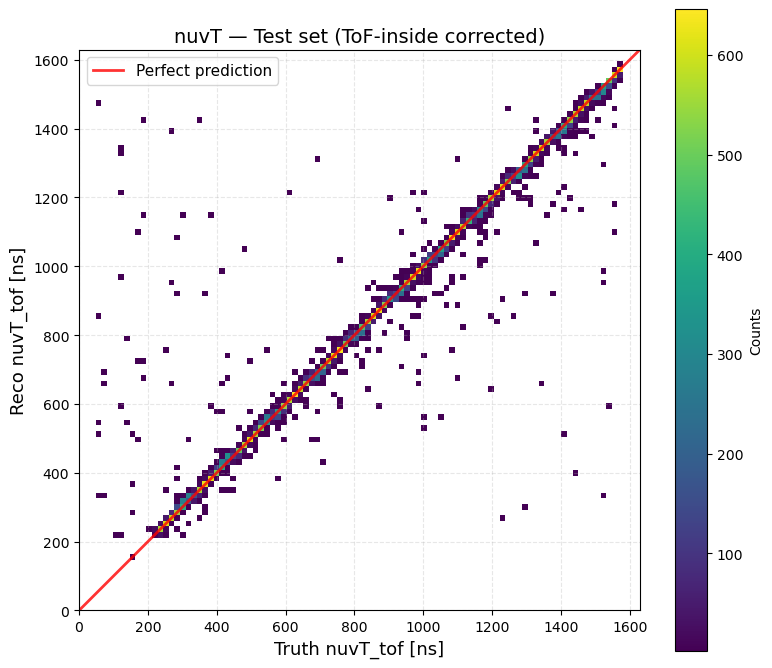

   [saved] fig_07_nuvT_—_Test_set_(ToF-inside_corrected).png


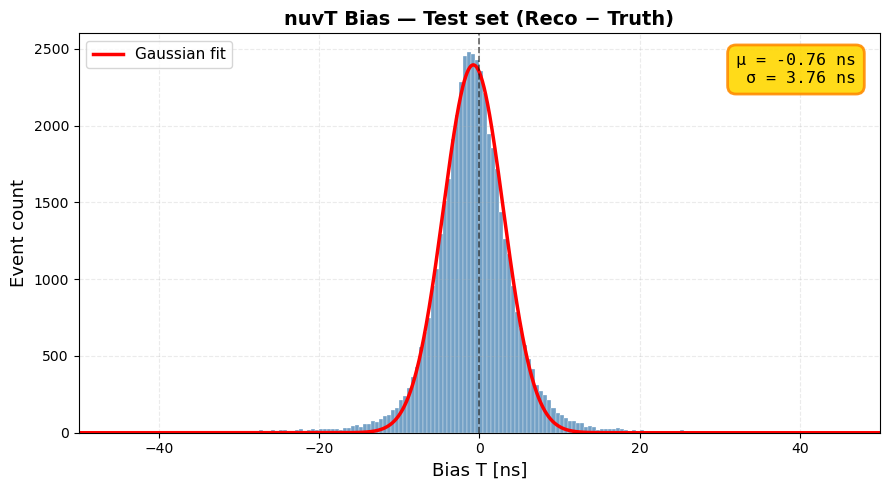

   [saved] fig_08_nuvT_Bias_—_Test_set_(Reco_−_Truth).png


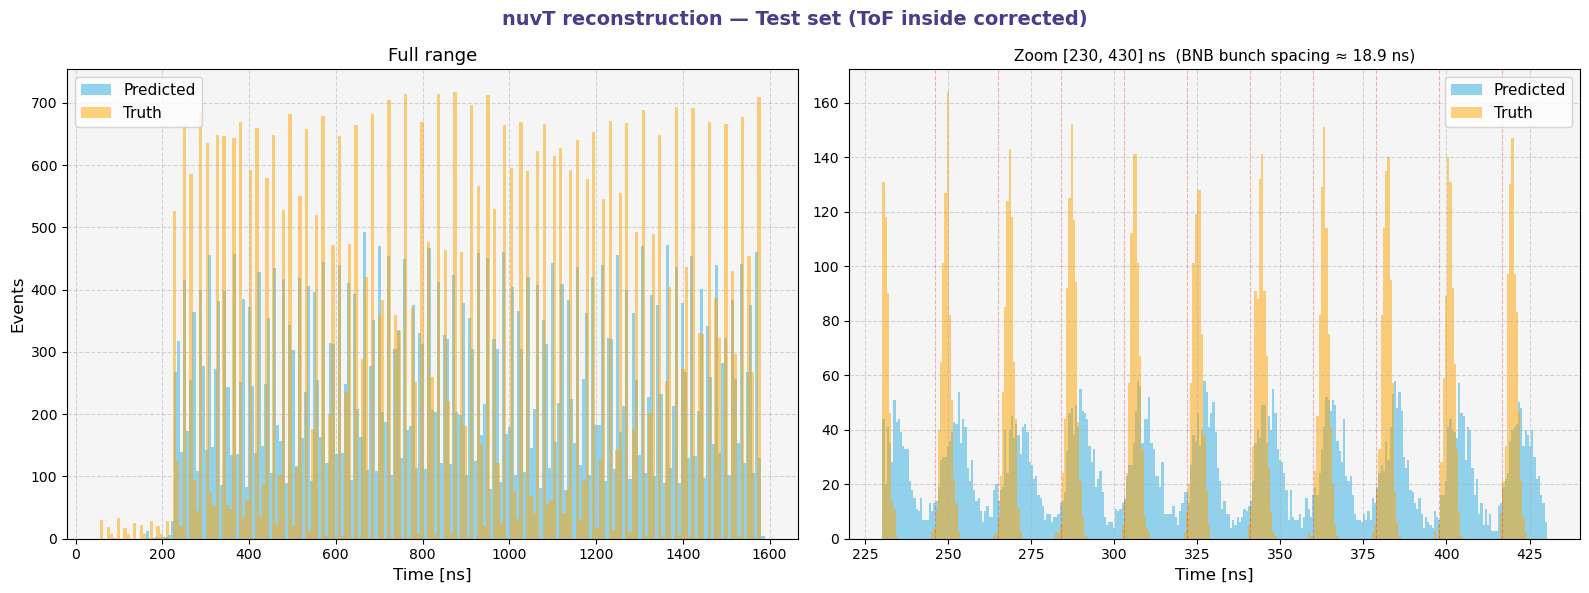

   [saved] fig_09_nuvT_reconstruction_—_Test_set_(ToF_inside_corrected).png


In [58]:

# ── Test: 2D histogram truth vs reco ─────────────────────────────────────────
RANGE_MIN, RANGE_MAX, CMIN = 0, None, 2
rmin = RANGE_MIN
rmax = y_test_ns.max() + 50 if RANGE_MAX is None else RANGE_MAX
rng  = [[rmin, rmax]] * 2

fig, ax = plt.subplots(figsize=(8, 7))
hist = ax.hist2d(y_test_ns, y_pred_test_ns, bins=100, cmap='viridis', cmin=CMIN, range=rng)
fig.colorbar(hist[3], ax=ax, label='Counts')
ax.plot(rng[0], rng[0], 'r-', linewidth=2, alpha=0.8, label='Perfect prediction')
ax.set_xlabel('Truth nuvT_tof [ns]', fontsize=13)
ax.set_ylabel('Reco nuvT_tof [ns]',  fontsize=13)
ax.set_title('nuvT — Test set (ToF-inside corrected)', fontsize=14)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
savefig(fig)

# ── Test: bias histogram ──────────────────────────────────────────────────────
BIAS_RANGE = (-50, 50)
BIN_WIDTH  = 0.5
bins_bias  = np.arange(BIAS_RANGE[0], BIAS_RANGE[1] + BIN_WIDTH, BIN_WIDTH)

fig, ax = plt.subplots(figsize=(9, 5))
counts_b, edges_b, _ = ax.hist(residuals_test, bins=bins_bias,
                                alpha=0.75, color='steelblue', edgecolor='white', linewidth=0.3)
bin_centers_b = (edges_b[:-1] + edges_b[1:]) / 2

try:
    popt_t, _ = curve_fit(gaussian, bin_centers_b, counts_b,
                          p0=[counts_b.max(), residuals_test.mean(), residuals_test.std()],
                          maxfev=20000)
    mu_t, sigma_t = popt_t[1], abs(popt_t[2])
    ax.plot(np.linspace(*BIAS_RANGE, 2000), gaussian(np.linspace(*BIAS_RANGE, 2000), *popt_t),
            'r-', linewidth=2.5, label='Gaussian fit')
except Exception:
    mu_t, sigma_t = residuals_test.mean(), residuals_test.std()

ax.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
ax.set_xlabel('Bias T [ns]', fontsize=13)
ax.set_ylabel('Event count', fontsize=13)
ax.set_title('nuvT Bias — Test set (Reco − Truth)', fontsize=14, fontweight='bold')
ax.set_xlim(BIAS_RANGE)
ax.grid(True, alpha=0.25, linestyle='--')
ax.legend(fontsize=11)
ax.text(0.97, 0.95, f'μ = {mu_t:.2f} ns\nσ = {sigma_t:.2f} ns',
    transform=ax.transAxes, fontsize=12, va='top', ha='right', family='monospace',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='gold', edgecolor='darkorange', linewidth=2, alpha=0.9))
plt.tight_layout()
plt.show()
savefig(fig)

# ── Test: distributions + zoom ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('nuvT reconstruction — Test set (ToF inside corrected)', fontsize=14, fontweight='bold', color='darkslateblue')

ax = axes[0]
ax.hist(y_pred_test_ns, bins=200, color='skyblue', alpha=0.9, label='Predicted')
ax.hist(y_test_ns,      bins=200, color='orange',  alpha=0.5, label='Truth')
ax.set_title('Full range', fontsize=13)
ax.set_xlabel('Time [ns]', fontsize=12)
ax.set_ylabel('Events', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor('whitesmoke')

ax = axes[1]
zoom_min = float(np.percentile(y_test_ns, 1))
zoom_max = zoom_min + 200
ax.hist(y_pred_test_ns, bins=300, range=(zoom_min, zoom_max), color='skyblue', alpha=0.9, label='Predicted')
ax.hist(y_test_ns,      bins=300, range=(zoom_min, zoom_max), color='orange',  alpha=0.5, label='Truth')
ax.set_title(f'Zoom [{zoom_min:.0f}, {zoom_max:.0f}] ns  (BNB bunch spacing ≈ 18.9 ns)', fontsize=11)
ax.set_xlabel('Time [ns]', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor('whitesmoke')
RF_PERIOD_NS = 18.936
t0 = zoom_min + (RF_PERIOD_NS - (zoom_min % RF_PERIOD_NS))
for t_b in np.arange(t0, zoom_max, RF_PERIOD_NS):
    ax.axvline(t_b, color='red', alpha=0.3, linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()
savefig(fig)
